In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# L17

# Part 1

## Data

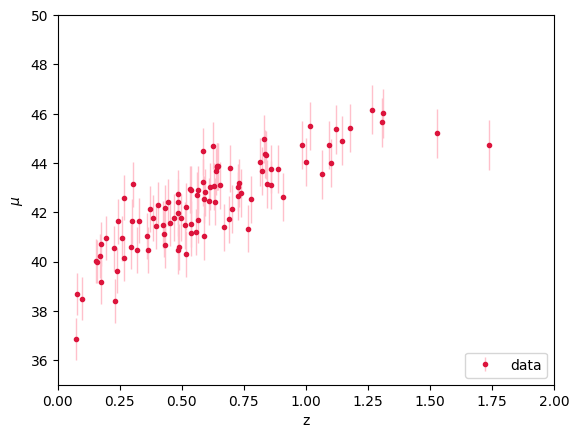

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.', c='crimson', ecolor='pink', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [3]:
X,y,dy = z_sample, mu_sample, dmu
X=X[:, np.newaxis]

## Linear

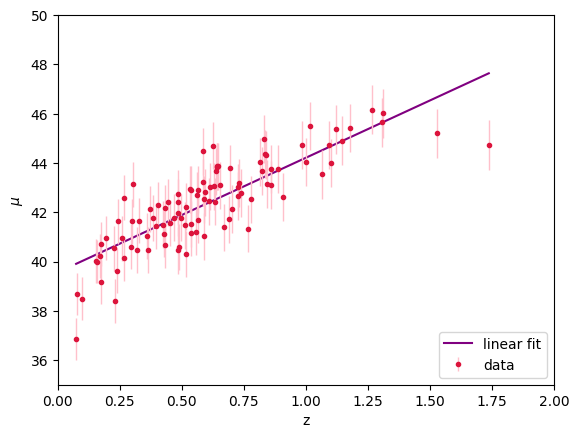

In [4]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

#print(theta0, theta1)
X_plot=np.array([np.min(X),np.max(X)])
X_plot=X_plot[:, np.newaxis]
y_pred=lin_reg.predict(X_plot)

plt.plot(X_plot,y_pred, c='purple', label='linear fit')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='pink',color='crimson',lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

## Polynomial

C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


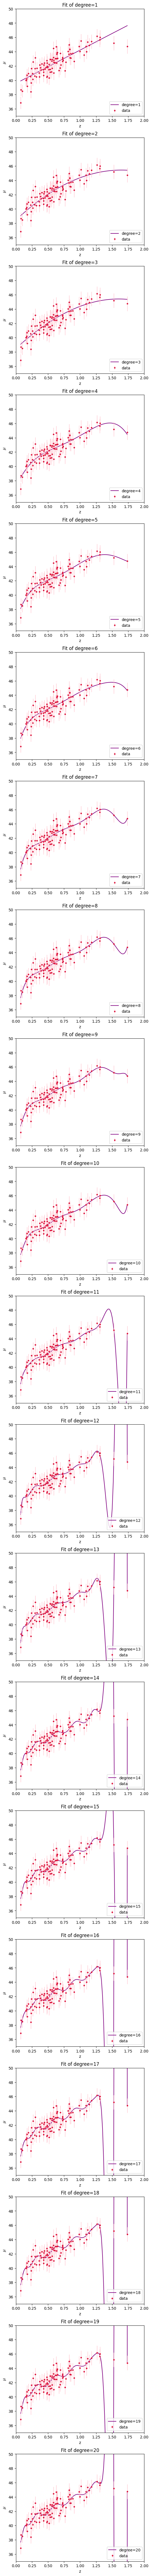

In [5]:
from astroML.linear_model import PolynomialRegression

fig=plt.figure(figsize=[6,120])

degrees=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
for i in range(len(degrees)):
    degree=degrees[i]
    ax=fig.add_subplot(len(degrees),1,degree)
    
    model = PolynomialRegression(degree)
    model.fit(X, y)

    n_constraints = degree + 1
    
    X_plot=np.linspace(np.min(X),np.max(X),100)
    X_plot=X_plot[:, np.newaxis]
    y_pred = model.predict(X_plot)
    
    ax.plot(X_plot,y_pred, c='purple', label='degree='+str(degree))
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='pink',color='crimson',lw=1,label='data')
    ax.set_xlabel("z")
    ax.set_ylabel(r"$\mu$")
    ax.legend(loc='lower right')
    ax.set_xlim(0,2)
    ax.set_ylim(35,50);
    ax.set_title("Fit of degree="+str(degree))

The third degree polynomial seems to fit quite well!

## Cross validation

In [6]:
from sklearn.model_selection import train_test_split

Xtrain, Xcv, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
ytrain,dytrain = ydy_train.T
ycv,dycv = ydy_validation.T

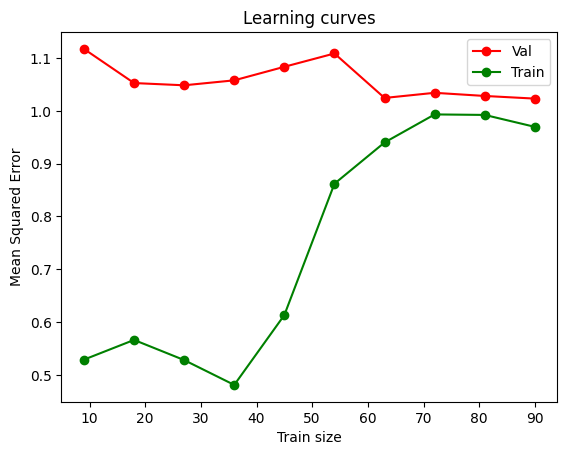

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

lin_reg = LinearRegression()
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(lin_reg, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)


plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

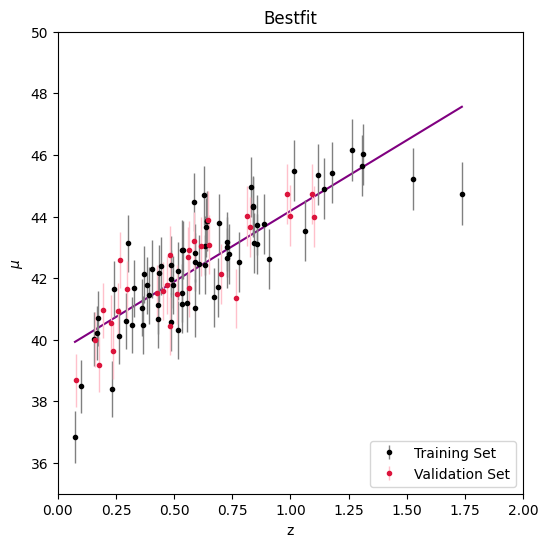

In [8]:
fig = plt.figure(figsize=(6, 6))
model = LinearRegression()
model.fit(Xtrain, ytrain)
    
X_plot=np.linspace(np.min(X),np.max(X),100)
X_plot=X_plot[:, np.newaxis]
y_pred = model.predict(X_plot)
    
plt.plot(X_plot,y_pred, c='purple')
plt.errorbar(Xtrain, ytrain, dytrain, fmt='.', ecolor='gray',color='k',lw=1,label='Training Set')
plt.errorbar(Xcv, ycv, dycv, fmt='.', ecolor='pink',color='crimson',lw=1,label='Validation Set')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);
plt.title("Bestfit");

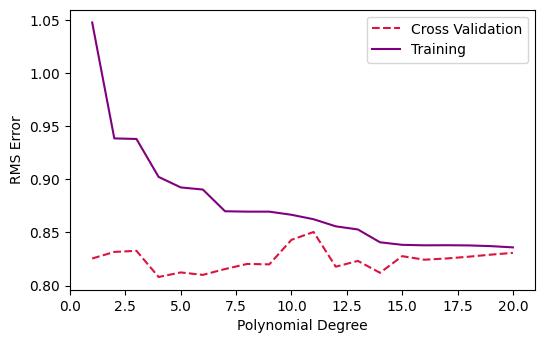

In [9]:
fig = plt.figure(figsize=(6, 8))

degrees=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
training_err=np.zeros(len(degrees))
crossval_err=np.zeros(len(degrees))
for i in range(len(degrees)):
    d=degrees[i]
    model = PolynomialRegression(d)
    model.fit(Xtrain, ytrain)
    training_err[i] =np.sqrt( np.sum(( ytrain - model.predict(Xtrain) )**2) / len(Xtrain) )
    crossval_err[i] =np.sqrt( np.sum(( ycv - model.predict(Xcv) )**2) / len(Xcv) )
    crossval_err[i] = np.sqrt(np.sum((model.predict(Xcv) - ycv) ** 2) / len(ycv))

ax = fig.add_subplot(211)
ax.plot(degrees, crossval_err, '--', c="crimson", label='Cross Validation')
ax.plot(degrees, training_err, '-', c="purple", label='Training')

ax.set_xlim(0, 21)

ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('RMS Error')
ax.legend(loc="upper right");

In [10]:
best=degrees[np.argmin(crossval_err)]
print("Bestfit Polynomial degree", best)

Bestfit Polynomial degree 4


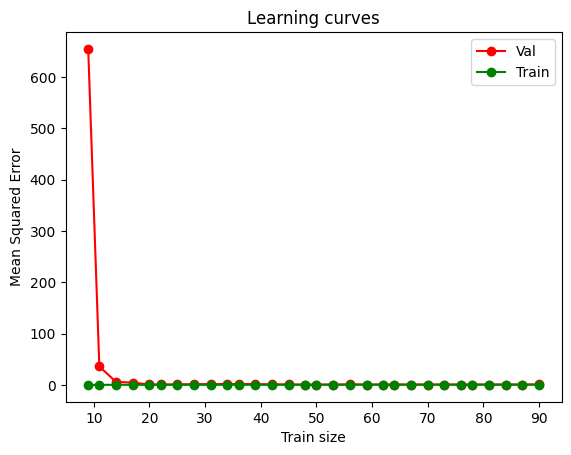

In [11]:
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

pol_reg = model = PolynomialRegression(best)
train_sizes, train_scores_polreg, test_scores_polreg = \
    learning_curve(pol_reg, Xscaled, y, train_sizes=np.linspace(0.1, 1, 30), \
    scoring="neg_mean_squared_error", cv=10)

plt.plot(train_sizes, -test_scores_polreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_polreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

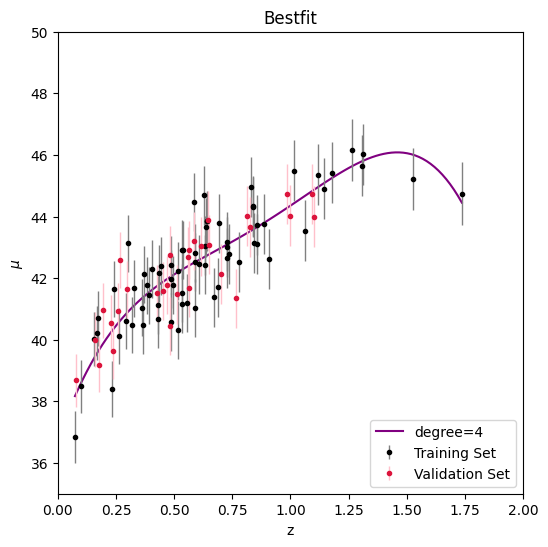

In [12]:
fig = plt.figure(figsize=(6, 6))
model = PolynomialRegression(best)
model.fit(Xtrain, ytrain)
    
X_plot=np.linspace(np.min(X),np.max(X),100)
X_plot=X_plot[:, np.newaxis]
y_pred = model.predict(X_plot)
    
plt.plot(X_plot,y_pred, c='purple', label='degree='+str(best))
plt.errorbar(Xtrain, ytrain, dytrain, fmt='.', ecolor='gray',color='k',lw=1,label='Training Set')
plt.errorbar(Xcv, ycv, dycv, fmt='.', ecolor='pink',color='crimson',lw=1,label='Validation Set')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);
plt.title("Bestfit");

# L18

# Part 2

## GPR

In [13]:
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.optimize import fmin_cobyla

In [14]:
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

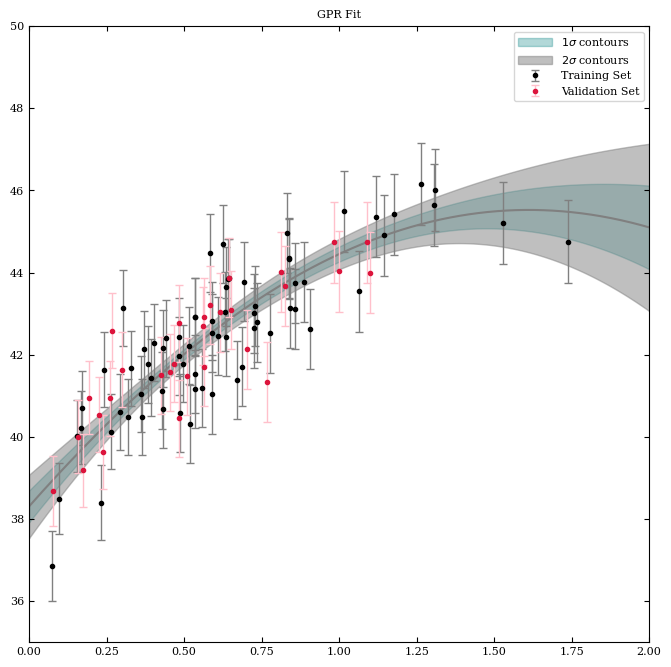

In [15]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gp3 = GaussianProcessRegressor(kernel=kernel,
                               alpha=(dytrain)**2,
                               random_state=0)
gp3.fit(Xtrain, ytrain)
Xv=np.sort(X)
x=np.linspace(0,2,1000)
x=x[:, np.newaxis]
f3, f3_err = gp3.predict(x, 
                         return_std=True)

fig=plt.figure(figsize=[8,8])
ax = fig.add_subplot(111)
x=x[:,0]

ax.plot(x, f3, color='gray')
ax.fill_between(x, f3 - f3_err, f3 + f3_err, 
                color='teal', alpha=0.3, label=r'$1\sigma$'+' contours')
ax.fill_between(x, f3 - 2 * f3_err, f3 + 2 * f3_err, 
                color='gray', alpha=0.5, label=r'$2\sigma$'+' contours')

ax.errorbar(Xtrain, ytrain, dytrain, fmt='.', ecolor='gray',color='k',lw=1,label='Training Set')
ax.errorbar(Xcv, ycv, dycv, fmt='.', ecolor='pink',color='crimson',lw=1,label='Validation Set')
ax.set_title('GPR Fit')
ax.set_xlim(0,2)
ax.set_ylim(35,50);

plt.legend();

## Cloning Data

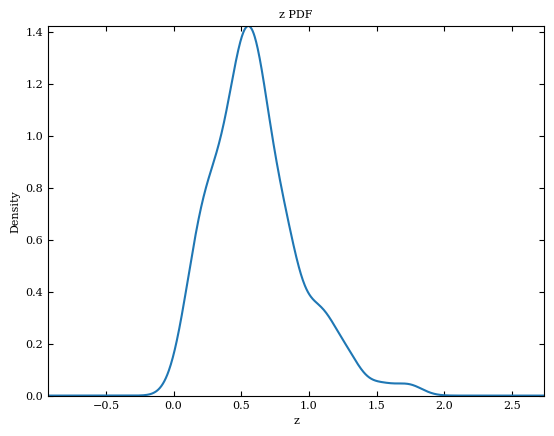

In [16]:
from sklearn.neighbors import KernelDensity

z_vals = np.array(z_sample).reshape(-1, 1) 

kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_vals)

z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)

plt.plot(z_plot[:, 0], dens)
plt.xlabel('z')
plt.ylabel('Density')
plt.title("z PDF");

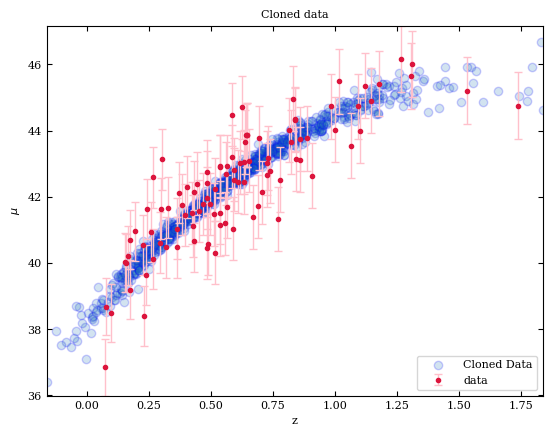

In [17]:
N = 1000
new_z_samples = kde.sample(N)

mu_gpr=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gp3.predict([[z]], 
                           return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))
    
plt.xlabel("z")
plt.ylabel(r"$\mu$")

plt.errorbar(z_sample, mu_sample, dmu, fmt='.', c='crimson', ecolor='pink', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")

plt.scatter(new_z_samples,mu_gpr,alpha=0.2, label='Cloned Data')
plt.title("Cloned data")
plt.legend(loc='lower right');

# Part 3

## Cosmology

In [18]:
from astropy.cosmology import LambdaCDM

def generativemodel(z, H0, Om=1):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om)
    return cosmo_tmp.distmod(z).value

## Nested Sampling: Real Universe

In [19]:
def Logprior(u):
    u[1]=u[1]*70+30
    u[0]=u[0]*0.99+0.01
    return u

def LogLikelihood(theta):
    Om,H0 = theta    
    if Om<0:
        return -np.inf
    else:
        mu_model = generativemodel(z_sample, H0, Om)
    return np.sum(scipy.stats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))

def LogPosterior(theta):
    return LogLikelihood(theta) + Logprior(theta)

In [20]:
import dynesty
ndim=2

In [21]:
sampler = dynesty.NestedSampler(LogLikelihood, Logprior, ndim,nlive=1000)
sampler.run_nested()
sresults = sampler.results

2761it [06:00,  7.66it/s, +1000 | bound: 0 | nc: 1 | ncall: 17192 | eff(%): 23.228 | loglstar:   -inf < -132.814 <    inf | logz: -135.302 +/-  0.022 | dlogz:  0.001 >  1.009]


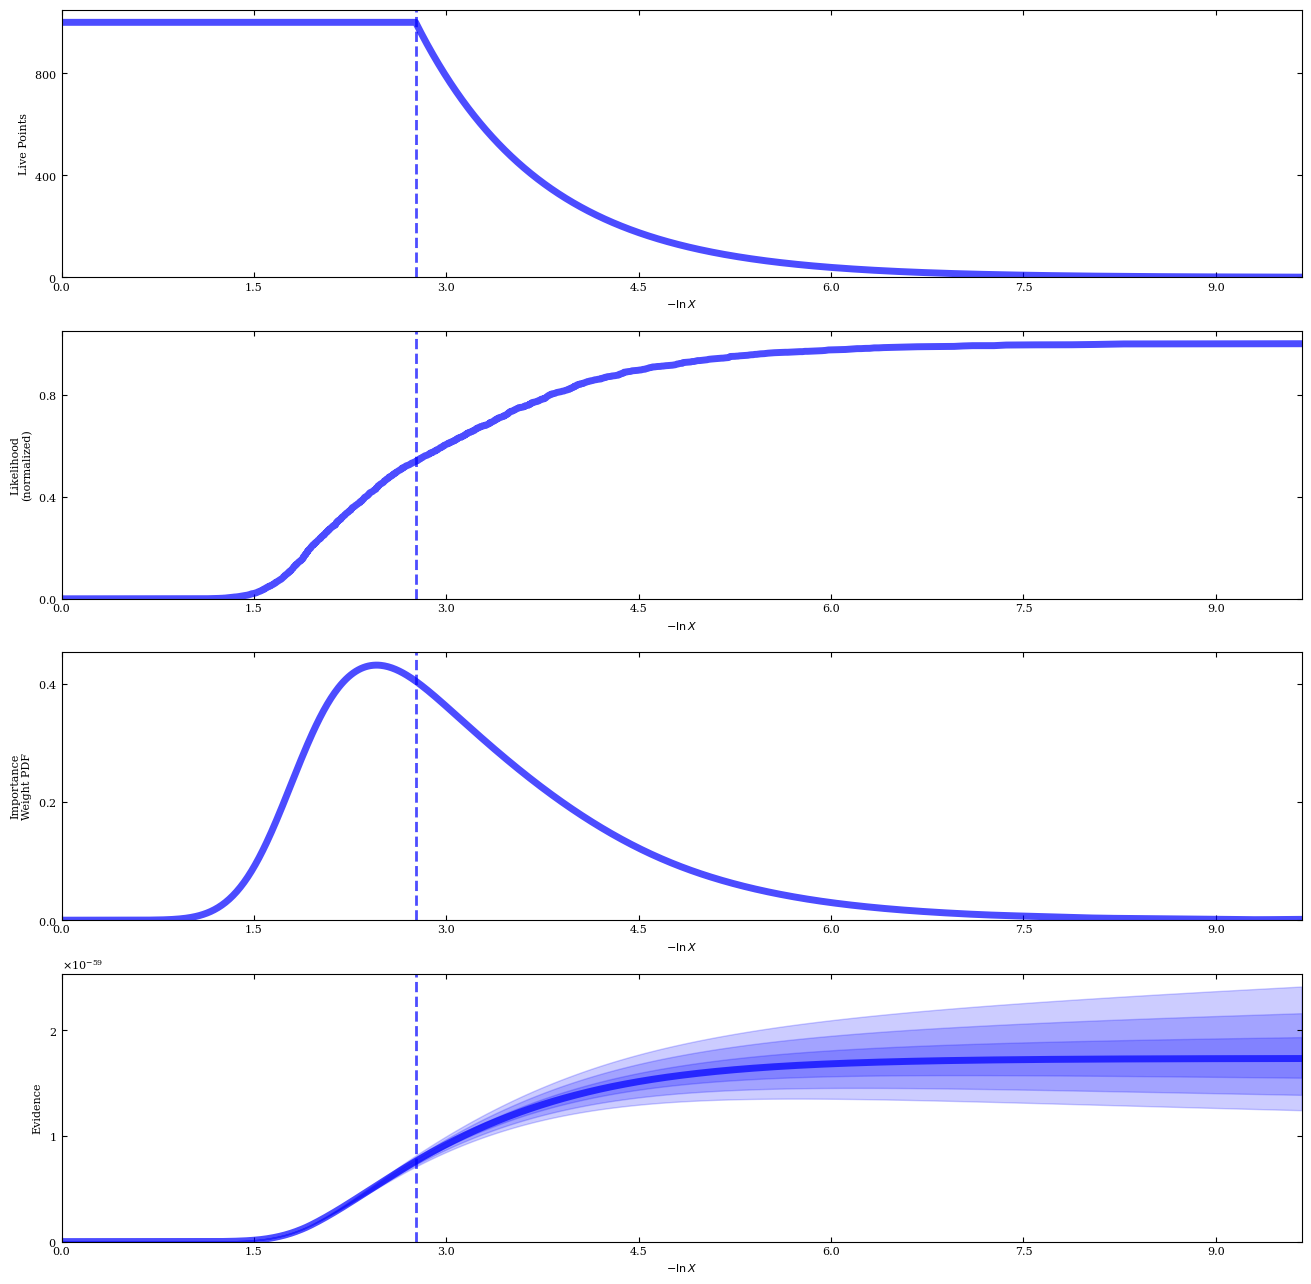

In [22]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

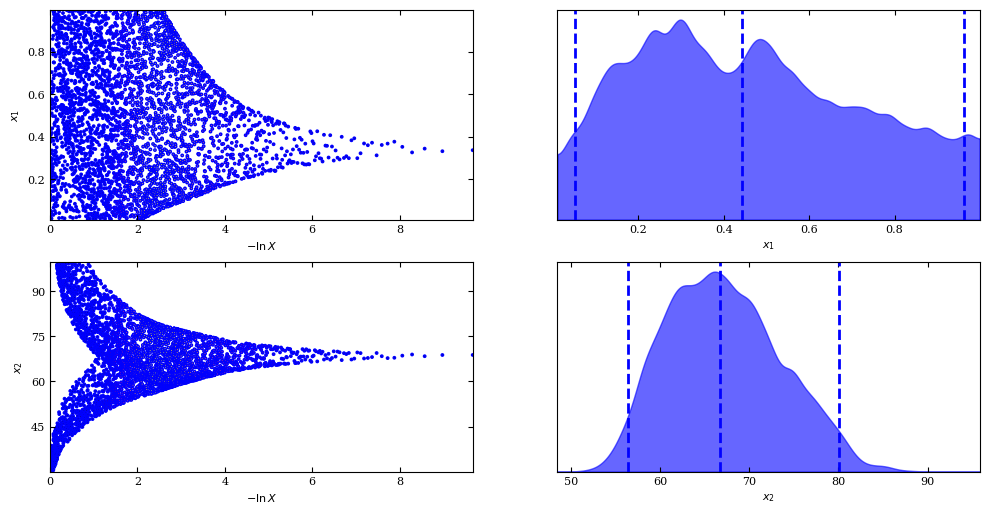

In [23]:
tfig, taxes = dyplot.traceplot(sresults)

In [24]:
from dynesty import utils as dyfunc


# Extract sampling results.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights


evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 1.733371102151007e-59
68% parameter credible regions are:
 [[0.1845073348825126, 0.7674814040134814], [60.51667682850421, 74.09573663607989]]

Mean and covariance of parameters are: [ 0.46274581 67.13263515]
[[ 0.06656579 -1.42757496]
 [-1.42757496 40.2445293 ]]


C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


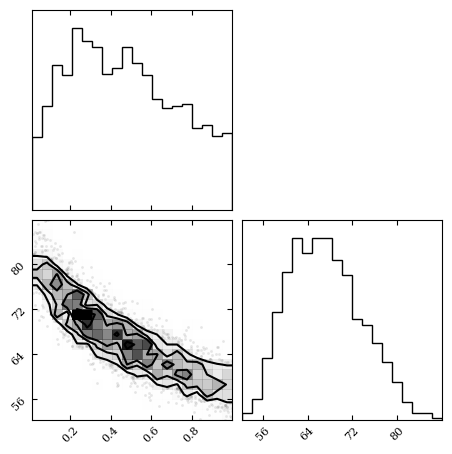

In [25]:
import corner
samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal);

In [26]:
labels = ['H_0','Omega_m']

quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

H_0   0.4423896454057107 +0.4772453277451473 -0.3550312927366466
Omega_m   66.69010933653608 +11.6878436624864 -9.042079595657626


## Nested Sampling: No Dark Energy

In [28]:
def Logprior(u):
    u[1]=u[1]*70+30
    u[0]=1
    return u

def LogLikelihood(theta):
    Om,H0 = theta    
    mu_model = generativemodel(z_sample, H0, Om)
    return np.sum(scipy.stats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))
                   
def LogPosterior(theta):
    return LogLikelihood(theta) + Logprior(theta)

In [29]:
import dynesty
ndim=2

In [30]:
sampler = dynesty.NestedSampler(LogLikelihood, Logprior, ndim, nlive=1000)
sampler.run_nested()
sresults2 = sampler.results

2833it [05:59,  7.88it/s, +1000 | bound: 0 | nc: 1 | ncall: 17511 | eff(%): 23.215 | loglstar:   -inf < -133.530 <    inf | logz: -135.984 +/-    nan | dlogz:  0.001 >  1.009]


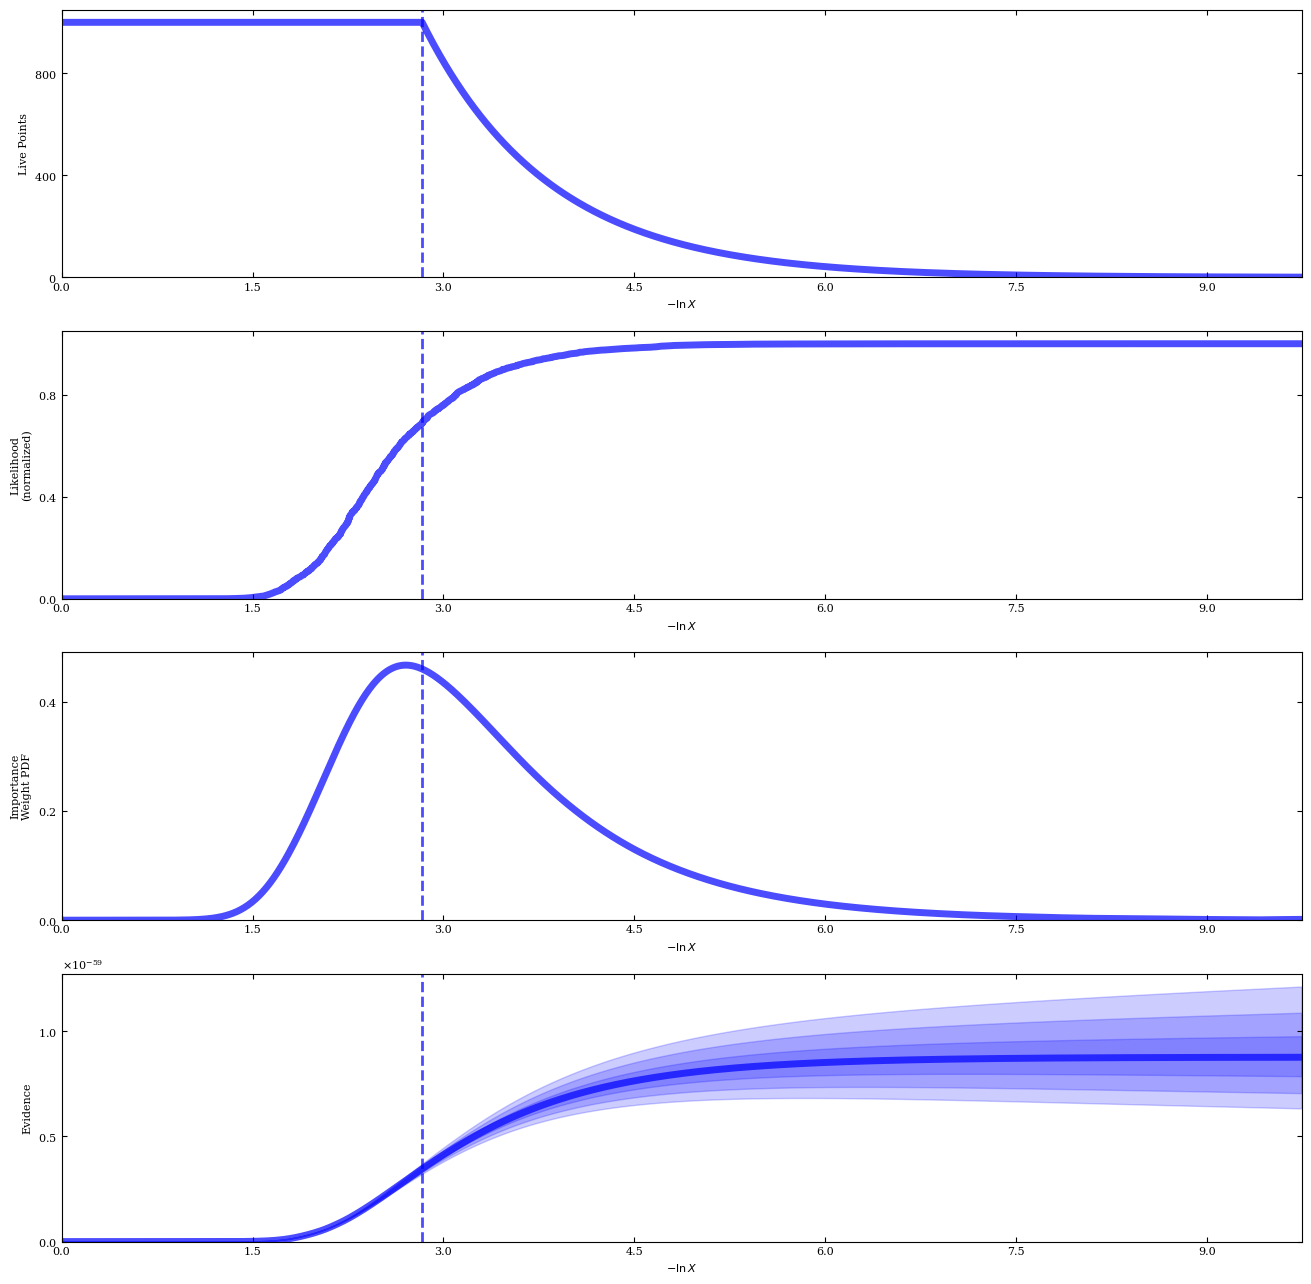

In [31]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults2)

C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dynesty\plotting.py:706: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min(x), max(x)])
C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dynesty\plotting.py:749: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(span[i])


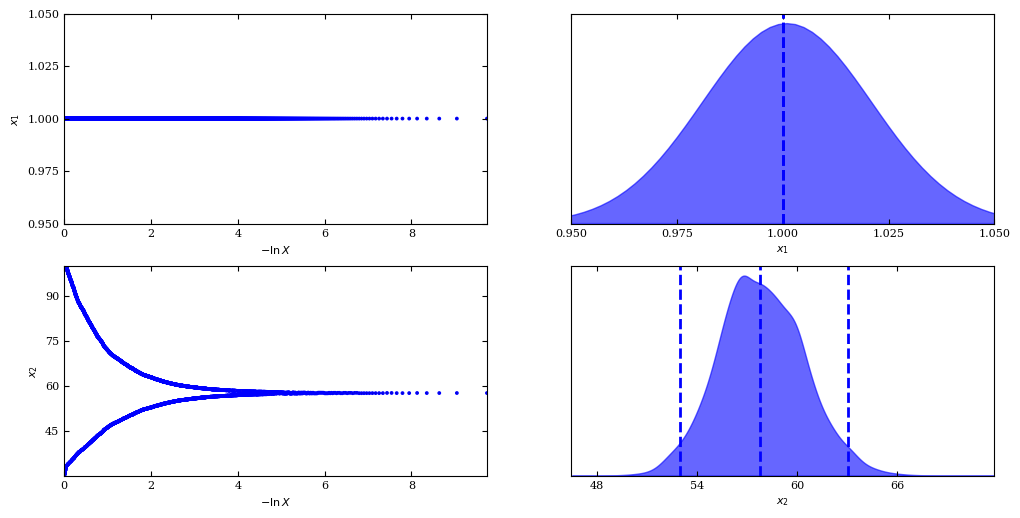

In [32]:
tfig, taxes = dyplot.traceplot(sresults2)

In [33]:
from dynesty import utils as dyfunc


# Extract sampling results.
samples = sresults2.samples  # samples
weights = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights


evidence2 = sresults2.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence2))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 8.767654623647552e-60
68% parameter credible regions are:
 [[1.0, 1.0], [55.40095067059997, 60.32878996131784]]

Mean and covariance of parameters are: [ 1.         57.84095399]
[[ 4.43967860e-31 -1.00777200e-28]
 [-1.00755244e-28  6.38102476e+00]]


In [34]:
labels = ['H_0','Omega_m']

quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

H_0   1.0 +0.0 -0.0
Omega_m   57.74774477927928 +4.340662568274972 -3.9659801833065984


In [35]:
bayes_factor=np.exp(evidence)/np.exp(evidence2)
if bayes_factor > 100: print(bayes_factor,'Decisive')
elif bayes_factor > 30: print(bayes_factor,'Very strong')
elif bayes_factor > 10: print(bayes_factor,'Strong')
elif bayes_factor > 3: print(bayes_factor,'Substantial')
elif bayes_factor > 1: print(bayes_factor,'Barely worth mentioning')
else: print('Negative')

1.9770065958983722 Barely worth mentioning
